In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import random
from torch.utils.data import random_split

SEED = 17

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

if device.type == "cuda":
    print(f"Название GPU: {torch.cuda.get_device_name(0)}")
    print(f"Количество GPU: {torch.cuda.device_count()}")

Используемое устройство: cuda
Название GPU: Tesla T4
Количество GPU: 1


Данные и DataLoader

Загрузить выбранный датасет через torchvision.datasets.*.

Определить transform (минимум ToTensor(), нормализация – по желанию).

Сделать разбиение train/val из train-части с фиксированным seed.

Создать DataLoader для train/val/test.

Показать sanity-check: размеры батча, shapes (x.shape, y.shape), диапазоны значений.


In [3]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

In [4]:
import torchvision

train_dataset_full = torchvision.datasets.EMNIST(
    root='./data',
    split='balanced',        # специальный balanced split
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.EMNIST(
    root='./data',
    split='balanced',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 562M/562M [00:06<00:00, 83.7MB/s]


In [5]:
print(f"Размер тренировочного набора: {len(train_dataset_full)}")
print(f"Размер тестового набора: {len(test_dataset)}")
print()

first_image, first_label = train_dataset_full[0]
print(f"Форма тензора с картинкой: {first_image.shape}")
print(f"Метка (класс): {first_label}")
print(f"Минимальное значение пикселя: {first_image.min()}")
print(f"Максимальное значение пикселя: {first_image.max()}")
print()

print(f"Всего классов: {len(train_dataset_full.classes)}")
print(f"Первые 10 классов: {train_dataset_full.classes[:10]}")

Размер тренировочного набора: 112800
Размер тестового набора: 18800

Форма тензора с картинкой: torch.Size([1, 28, 28])
Метка (класс): 45
Минимальное значение пикселя: 0.0
Максимальное значение пикселя: 1.0

Всего классов: 47
Первые 10 классов: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [6]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

split_generator = torch.Generator().manual_seed(SEED)

print(f"Полный тренировочный набор: {len(train_dataset_full)}")
print(f"80% для обучения: {train_size}")
print(f"20% для валидации: {val_size}")

Полный тренировочный набор: 112800
80% для обучения: 90240
20% для валидации: 22560


In [7]:
train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=split_generator
)

print(f"train_dataset: {len(train_dataset)}, val_dataset: {len(val_dataset)}")

train_dataset: 90240, val_dataset: 22560


In [8]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"train_loader: {len(train_loader)} батчей по {batch_size}")
print(f"val_loader: {len(val_loader)} батчей")
print(f"test_loader: {len(test_loader)} батчей")

train_loader: 1410 батчей по 64
val_loader: 353 батчей
test_loader: 294 батчей


In [9]:
first_batch = next(iter(train_loader))
images, labels = first_batch

print(f"Тип images: {type(images)}")
print(f"Тип labels: {type(labels)}")
print()
print(f"Форма images: {images.shape}")
print(f"Форма labels: {labels.shape}")
print()
print(f"Тип данных images: {images.dtype}")
print(f"Тип данных labels: {labels.dtype}")
print()
print(f"Минимальное значение в images: {images.min():.3f}")
print(f"Максимальное значение в images: {images.max():.3f}")
print(f"Среднее значение: {images.mean():.3f}")
print()
print(f"Первые 10 меток: {labels[:10]}")
print(f"Уникальные метки в батче: {torch.unique(labels)}")

Тип images: <class 'torch.Tensor'>
Тип labels: <class 'torch.Tensor'>

Форма images: torch.Size([64, 1, 28, 28])
Форма labels: torch.Size([64])

Тип данных images: torch.float32
Тип данных labels: torch.int64

Минимальное значение в images: 0.000
Максимальное значение в images: 1.000
Среднее значение: 0.175

Первые 10 меток: tensor([40, 37, 18, 45, 23,  3,  1, 32, 44,  2])
Уникальные метки в батче: tensor([ 0,  1,  2,  3,  4,  5,  6, 10, 11, 12, 13, 14, 16, 17, 18, 20, 21, 22,
        23, 24, 25, 27, 28, 29, 31, 32, 33, 34, 37, 38, 39, 40, 43, 44, 45, 46])


In [10]:
print(f"Данные лежат на: {images.device}")
print(device)


Данные лежат на: cpu
cuda


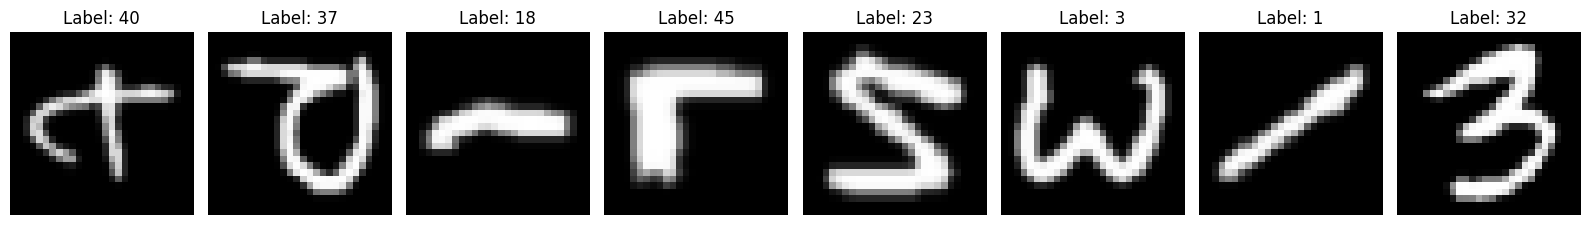

In [11]:
import matplotlib.pyplot as plt

def show_first_batch(images, labels, num_images=8):
    fig, axes = plt.subplots(1, num_images, figsize=(16, 4))
    for i in range(num_images):
        # (1, 28, 28) -> (28, 28)
        img = images[i].squeeze()
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {labels[i].item()}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Первые 8 картинок из батча
show_first_batch(images, labels, 8)

Модель MLP и цикл обучения

Реализовать MLP как nn.Module (Flatten, Linear, …, logits).


Выбрать:

loss: CrossEntropyLoss;

optimizer: Adam (по умолчанию для базовых экспериментов);

метрика: accuracy (достаточно).


Реализовать функции (или эквивалент):

train_one_epoch(...)

evaluate(...) (с model.eval() и torch.no_grad())


Логировать историю обучения: train/val loss и train/val accuracy по эпохам.

In [12]:
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, hidden_sizes=[128, 64], num_classes=47):
        super().__init__()

        # распрямление
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(784, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], num_classes)

    def forward(self, x):
        # x: [batch_size, 1, 28, 28]
        x = self.flatten(x)        # -> [batch_size, 784]
        x = F.relu(self.fc1(x))    # -> [batch_size, 128]
        x = F.relu(self.fc2(x))    # -> [batch_size, 64]
        x = self.fc3(x)            # -> [batch_size, 47]
        return x

model = MLP().to(device)
print(model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=47, bias=True)
)


In [13]:
# проверка
sample_batch = next(iter(train_loader))
sample_images, _ = sample_batch
sample_images = sample_images.to(device)

output = model(sample_images)
print(f"Вход: {sample_images.shape} -> Выход: {output.shape}")

Вход: torch.Size([64, 1, 28, 28]) -> Выход: torch.Size([64, 47])


In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters())

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [15]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        # Отправляем данные на устройство
        images = images.to(device)
        labels = labels.to(device)

        # Обнуляем градиент
        optimizer.zero_grad()

        # Прямой проход
        outputs = model(images)

        # Потери
        loss = criterion(outputs, labels)

        # Обратный проход
        loss.backward()

        # Обновляем веса
        optimizer.step()

        running_loss += loss.item()

        # Точность
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 100 == 0:
            print(f'  Батч {batch_idx + 1}/{len(train_loader)}, '
                  f'Loss: {loss.item():.4f}')

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

In [16]:
def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Прямой проход
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Точность
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(data_loader)
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

In [17]:
num_epochs = 10

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}


print(f"Всего эпох: {num_epochs}")
print(f"Устройство: {device}")
print(f"Тренировочных батчей: {len(train_loader)}")
print(f"Валидационных батчей: {len(val_loader)}")


for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(model, val_loader, criterion, device)


    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)


    print(f"Эпоха {epoch + 1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.2f}%")
    print()

Всего эпох: 10
Устройство: cuda
Тренировочных батчей: 1410
Валидационных батчей: 353
  Батч 100/1410, Loss: 2.2243
  Батч 200/1410, Loss: 1.5682
  Батч 300/1410, Loss: 1.9247
  Батч 400/1410, Loss: 1.1708
  Батч 500/1410, Loss: 1.0274
  Батч 600/1410, Loss: 1.4457
  Батч 700/1410, Loss: 1.0670
  Батч 800/1410, Loss: 1.2786
  Батч 900/1410, Loss: 1.1621
  Батч 1000/1410, Loss: 0.8055
  Батч 1100/1410, Loss: 0.8239
  Батч 1200/1410, Loss: 1.0669
  Батч 1300/1410, Loss: 0.9711
  Батч 1400/1410, Loss: 1.1056
Эпоха 1/10
  Train Loss: 1.3012, Train Acc: 63.07%
  Val Loss:   0.8825, Val Acc:   73.05%

  Батч 100/1410, Loss: 1.0124
  Батч 200/1410, Loss: 0.8089
  Батч 300/1410, Loss: 0.7857
  Батч 400/1410, Loss: 0.7789
  Батч 500/1410, Loss: 0.8192
  Батч 600/1410, Loss: 0.5457
  Батч 700/1410, Loss: 0.5209
  Батч 800/1410, Loss: 0.5962
  Батч 900/1410, Loss: 0.6877
  Батч 1000/1410, Loss: 0.6381
  Батч 1100/1410, Loss: 0.5613
  Батч 1200/1410, Loss: 0.5714
  Батч 1300/1410, Loss: 0.8863
  Ба

In [18]:
print("Итоговые результаты после 10 эпох:")
print(f"Лучшая точность на валидации: {max(history['val_acc']):.2f}%")
print(f"Финальная точность на валидации: {history['val_acc'][-1]:.2f}%")
print(f"Финальная точность на тренировке: {history['train_acc'][-1]:.2f}%")

Итоговые результаты после 10 эпох:
Лучшая точность на валидации: 82.42%
Финальная точность на валидации: 82.42%
Финальная точность на тренировке: 85.75%


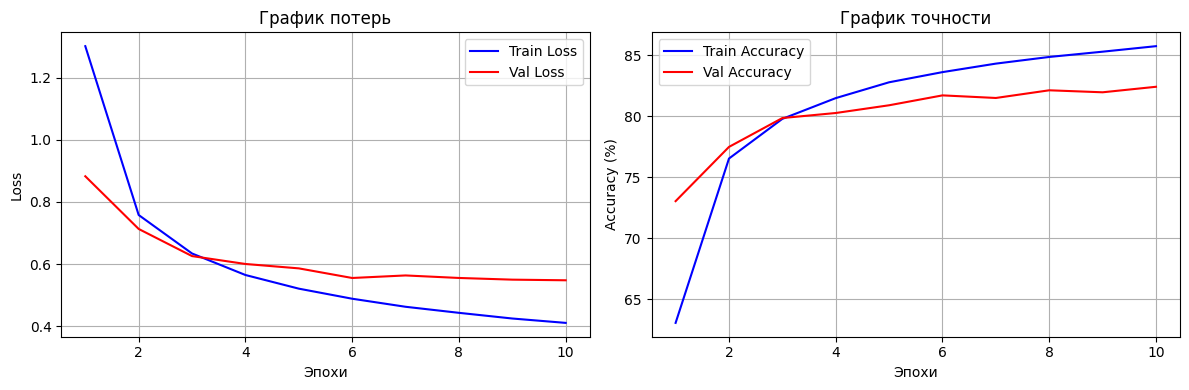

In [19]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.title('График потерь')
plt.legend()
plt.grid(True)

# График точности
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], 'b-', label='Train Accuracy')
plt.plot(epochs, history['val_acc'], 'r-', label='Val Accuracy')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy (%)')
plt.title('График точности')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print()
print("Сравнение с валидацией:")
print(f"Val Accuracy (лучшая): {max(history['val_acc']):.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

Test Loss: 0.5649
Test Accuracy: 82.46%

Сравнение с валидацией:
Val Accuracy (лучшая): 82.42%
Test Accuracy: 82.46%


3.1. Часть A (S08): регуляризация и переобучение (обязательно)
Задача: показать эффект Dropout/BatchNorm и ранней остановки.

Провести 4 эксперимента (E1-E4). Эксперимент = фиксированный конфиг модели/обучения + обучение + оценка на val.

E1 (base): MLP побольше (например, 2-3 скрытых слоя), без Dropout и без BatchNorm.
E2 (Dropout): как E1, но добавить Dropout (например, p=0.2-0.5).
E3 (BatchNorm): как E1, но добавить BatchNorm (между Linear и активацией).
E4 (EarlyStopping): выбрать лучший из (E2/E3) по val_accuracy и обучить его с EarlyStopping (patience 3-5).
именно E4 считается "лучшей моделью домашки" и из него сохраняется best_model.pt.
Важно:

сравнение должно быть корректным: одинаковые split/train settings (где уместно), одинаковое число эпох (кроме early stopping);
test-часть используйте один раз: только для финальной оценки лучшей модели после выбора по val.

In [21]:
class MLP_large(nn.Module):
    def __init__(self, dropout_prob=0.0, use_batchnorm=False):
        super().__init__()

        self.flatten = nn.Flatten()
        self.use_batchnorm = use_batchnorm

        self.fc1 = nn.Linear(784, 256)
        if use_batchnorm:
            self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 128)
        if use_batchnorm:
            self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128, 64)
        if use_batchnorm:
            self.bn3 = nn.BatchNorm1d(64)

        self.fc4 = nn.Linear(64, 47)

        # Dropout
        self.dropout = nn.Dropout(dropout_prob) if dropout_prob > 0 else None

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = F.relu(x)

        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = F.relu(x)

        x = self.fc3(x)
        if self.use_batchnorm:
            x = self.bn3(x)
        x = F.relu(x)

        if self.dropout is not None:
            x = self.dropout(x)

        x = self.fc4(x)

        return x

In [22]:
def run_experiment(model, train_loader, val_loader, num_epochs=10, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model = model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_loss = float("inf")
    best_val_epoch = -1

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_epoch = epoch + 1

        print(f"Эпоха {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

    return history, model, best_val_loss, best_val_epoch

In [23]:
print("E1 (Base)")

model_e1 = MLP_large(
    dropout_prob=0.0,
    use_batchnorm=False
)

total_params = sum(p.numel() for p in model_e1.parameters())
print(f"Модель создана. Параметров: {total_params:,}")


history_e1, best_model_e1, best_val_loss_e1, best_val_epoch_e1 = run_experiment(
    model=model_e1,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=10,
    lr=0.001
)

import pandas as pd

e1_results = {
    'experiment': 'E1_base',
    'dropout': 0.0,
    'batchnorm': False,
    'final_train_acc': history_e1['train_acc'][-1],
    'final_val_acc': history_e1['val_acc'][-1],
    'best_val_acc': max(history_e1['val_acc']),
    'best_epoch': history_e1['val_acc'].index(max(history_e1['val_acc'])) + 1
}

print(f"Лучшая точность на валидации: {e1_results['best_val_acc']:.2f}% на эпохе {e1_results['best_epoch']}")
print(f"Финальная точность на валидации: {e1_results['final_val_acc']:.2f}%")

E1 (Base)
Модель создана. Параметров: 245,167
  Батч 100/1410, Loss: 2.1996
  Батч 200/1410, Loss: 1.4517
  Батч 300/1410, Loss: 1.5239
  Батч 400/1410, Loss: 1.2726
  Батч 500/1410, Loss: 1.1041
  Батч 600/1410, Loss: 0.9056
  Батч 700/1410, Loss: 1.0558
  Батч 800/1410, Loss: 0.9295
  Батч 900/1410, Loss: 0.6078
  Батч 1000/1410, Loss: 1.0454
  Батч 1100/1410, Loss: 0.4802
  Батч 1200/1410, Loss: 0.9492
  Батч 1300/1410, Loss: 0.6650
  Батч 1400/1410, Loss: 0.8328
Эпоха 1: Train Acc=64.80%, Val Acc=75.79%
  Батч 100/1410, Loss: 0.5364
  Батч 200/1410, Loss: 0.8008
  Батч 300/1410, Loss: 0.5467
  Батч 400/1410, Loss: 0.8497
  Батч 500/1410, Loss: 0.7385
  Батч 600/1410, Loss: 0.8036
  Батч 700/1410, Loss: 1.3113
  Батч 800/1410, Loss: 0.5059
  Батч 900/1410, Loss: 0.5762
  Батч 1000/1410, Loss: 0.3565
  Батч 1100/1410, Loss: 0.6016
  Батч 1200/1410, Loss: 0.4121
  Батч 1300/1410, Loss: 0.7347
  Батч 1400/1410, Loss: 0.6177
Эпоха 2: Train Acc=78.97%, Val Acc=80.04%
  Батч 100/1410, Los

In [24]:
print("E2 (Dropout)")

model_e2 = MLP_large(
    dropout_prob=0.3,
    use_batchnorm=False
)

total_params = sum(p.numel() for p in model_e2.parameters())
print(f"Модель создана. Параметров: {total_params:,}")

history_e2, best_model_e2, best_val_loss_e2, best_val_epoch_e2 = run_experiment(
    model=model_e2,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=10,
    lr=0.001
)


e2_results = {
    'experiment': 'E2_dropout',
    'dropout': 0.3,
    'batchnorm': False,
    'final_train_acc': history_e2['train_acc'][-1],
    'final_val_acc': history_e2['val_acc'][-1],
    'best_val_acc': max(history_e2['val_acc']),
    'best_epoch': history_e2['val_acc'].index(max(history_e2['val_acc'])) + 1
}

print(f"Лучшая точность на валидации: {e2_results['best_val_acc']:.2f}% на эпохе {e2_results['best_epoch']}")
print(f"Финальная точность на валидации: {e2_results['final_val_acc']:.2f}%")

E2 (Dropout)
Модель создана. Параметров: 245,167
  Батч 100/1410, Loss: 2.8596
  Батч 200/1410, Loss: 2.0044
  Батч 300/1410, Loss: 1.4982
  Батч 400/1410, Loss: 1.4273
  Батч 500/1410, Loss: 0.9785
  Батч 600/1410, Loss: 1.2863
  Батч 700/1410, Loss: 1.5679
  Батч 800/1410, Loss: 0.9455
  Батч 900/1410, Loss: 1.3938
  Батч 1000/1410, Loss: 1.3322
  Батч 1100/1410, Loss: 1.2685
  Батч 1200/1410, Loss: 1.1064
  Батч 1300/1410, Loss: 1.0400
  Батч 1400/1410, Loss: 0.8998
Эпоха 1: Train Acc=57.21%, Val Acc=75.11%
  Батч 100/1410, Loss: 1.0165
  Батч 200/1410, Loss: 0.6917
  Батч 300/1410, Loss: 0.6281
  Батч 400/1410, Loss: 0.5912
  Батч 500/1410, Loss: 1.0964
  Батч 600/1410, Loss: 0.6537
  Батч 700/1410, Loss: 0.8239
  Батч 800/1410, Loss: 0.7816
  Батч 900/1410, Loss: 0.9424
  Батч 1000/1410, Loss: 1.1191
  Батч 1100/1410, Loss: 1.1480
  Батч 1200/1410, Loss: 0.8952
  Батч 1300/1410, Loss: 0.8768
  Батч 1400/1410, Loss: 0.7797
Эпоха 2: Train Acc=74.15%, Val Acc=79.23%
  Батч 100/1410, 

In [25]:
print("E3 (BatchNorm)")

model_e3 = MLP_large(
    dropout_prob=0.0,
    use_batchnorm=True
)

total_params = sum(p.numel() for p in model_e3.parameters())
print(f"Модель создана. Параметров: {total_params:,}")

history_e3, best_model_e3, best_val_loss_e3, best_val_epoch_e3 = run_experiment(
    model=model_e3,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=10,
    lr=0.001
)

e3_results = {
    'experiment': 'E3_batchnorm',
    'dropout': 0.0,
    'batchnorm': True,
    'final_train_acc': history_e3['train_acc'][-1],
    'final_val_acc': history_e3['val_acc'][-1],
    'best_val_acc': max(history_e3['val_acc']),
    'best_epoch': history_e3['val_acc'].index(max(history_e3['val_acc'])) + 1
}

print(f"Лучшая точность на валидации: {e3_results['best_val_acc']:.2f}% на эпохе {e3_results['best_epoch']}")
print(f"Финальная точность на валидации: {e3_results['final_val_acc']:.2f}%")


E3 (BatchNorm)
Модель создана. Параметров: 246,063
  Батч 100/1410, Loss: 2.2145
  Батч 200/1410, Loss: 1.5531
  Батч 300/1410, Loss: 0.9897
  Батч 400/1410, Loss: 0.9990
  Батч 500/1410, Loss: 0.7774
  Батч 600/1410, Loss: 0.8382
  Батч 700/1410, Loss: 0.7058
  Батч 800/1410, Loss: 0.6210
  Батч 900/1410, Loss: 0.6487
  Батч 1000/1410, Loss: 0.6158
  Батч 1100/1410, Loss: 0.8627
  Батч 1200/1410, Loss: 0.5844
  Батч 1300/1410, Loss: 0.4308
  Батч 1400/1410, Loss: 0.6525
Эпоха 1: Train Acc=72.34%, Val Acc=80.63%
  Батч 100/1410, Loss: 0.5017
  Батч 200/1410, Loss: 0.5240
  Батч 300/1410, Loss: 0.6671
  Батч 400/1410, Loss: 0.6521
  Батч 500/1410, Loss: 0.6315
  Батч 600/1410, Loss: 0.4958
  Батч 700/1410, Loss: 0.6719
  Батч 800/1410, Loss: 0.6388
  Батч 900/1410, Loss: 0.8438
  Батч 1000/1410, Loss: 0.6235
  Батч 1100/1410, Loss: 0.5970
  Батч 1200/1410, Loss: 0.7911
  Батч 1300/1410, Loss: 0.7414
  Батч 1400/1410, Loss: 0.3916
Эпоха 2: Train Acc=81.31%, Val Acc=82.63%
  Батч 100/1410

In [26]:
print("E4 (Early Stopping)")

class EarlyStopping:
    def __init__(self, patience=3, verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_acc, model):
        if self.best_score is None:
            self.best_score = val_acc
            self.best_model_state = model.state_dict().copy()
        elif val_acc > self.best_score:
            self.best_score = val_acc
            self.best_model_state = model.state_dict().copy()
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


model_e4 = MLP_large(
    dropout_prob=0.0,
    use_batchnorm=True
)

print(f"Модель создана. Параметров: {sum(p.numel() for p in model_e4.parameters()):,}")

optimizer = optim.Adam(model_e4.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
model_e4 = model_e4.to(device)

history_e4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
early_stopping = EarlyStopping(patience=3, verbose=True)

for epoch in range(20):
    train_loss, train_acc = train_one_epoch(
        model_e4, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(model_e4, val_loader, criterion, device)

    history_e4['train_loss'].append(train_loss)
    history_e4['train_acc'].append(train_acc)
    history_e4['val_loss'].append(val_loss)
    history_e4['val_acc'].append(val_acc)

    print(f"Эпоха {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

    early_stopping(val_acc, model_e4)

    if early_stopping.early_stop:
        print(f"\nОбучение остановлено на эпохе {epoch+1}")
        break

model_e4.load_state_dict(early_stopping.best_model_state)

best_val_loss_e4 = min(history_e4['val_loss'])
best_val_epoch_e4 = history_e4['val_loss'].index(best_val_loss_e4) + 1

print(f"Лучшая точность на валидации: {early_stopping.best_score:.2f}%")
print(f"Достигнута на эпохе: {history_e4['val_acc'].index(early_stopping.best_score) + 1}")

print(f"Лучшая точность на валидации: {early_stopping.best_score:.2f}%")
print(f"Достигнута на эпохе: {history_e4['val_acc'].index(early_stopping.best_score) + 1}")


E4 (Early Stopping)
Модель создана. Параметров: 246,063
  Батч 100/1410, Loss: 2.1403
  Батч 200/1410, Loss: 1.1179
  Батч 300/1410, Loss: 1.2948
  Батч 400/1410, Loss: 0.9874
  Батч 500/1410, Loss: 0.7801
  Батч 600/1410, Loss: 0.9339
  Батч 700/1410, Loss: 0.6651
  Батч 800/1410, Loss: 0.6650
  Батч 900/1410, Loss: 0.7007
  Батч 1000/1410, Loss: 0.6331
  Батч 1100/1410, Loss: 0.6545
  Батч 1200/1410, Loss: 0.7777
  Батч 1300/1410, Loss: 0.3516
  Батч 1400/1410, Loss: 0.6961
Эпоха 1: Train Acc=72.41%, Val Acc=81.05%
  Батч 100/1410, Loss: 0.4417
  Батч 200/1410, Loss: 0.5517
  Батч 300/1410, Loss: 0.5133
  Батч 400/1410, Loss: 0.6609
  Батч 500/1410, Loss: 0.8843
  Батч 600/1410, Loss: 0.7382
  Батч 700/1410, Loss: 0.3518
  Батч 800/1410, Loss: 0.7138
  Батч 900/1410, Loss: 0.5388
  Батч 1000/1410, Loss: 0.4136
  Батч 1100/1410, Loss: 0.5437
  Батч 1200/1410, Loss: 0.5008
  Батч 1300/1410, Loss: 0.7559
  Батч 1400/1410, Loss: 0.6168
Эпоха 2: Train Acc=81.59%, Val Acc=82.21%
  Батч 100

In [27]:
torch.save(model_e4.state_dict(), 'best_model.pt')
print("Лучшая модель сохранена как 'best_model.pt'")

Лучшая модель сохранена как 'best_model.pt'


In [28]:
model_final = MLP_large(dropout_prob=0.0, use_batchnorm=True)
model_final.load_state_dict(torch.load('best_model.pt'))
model_final = model_final.to(device)

test_loss, test_acc = evaluate(model_final, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print()
print("Сравнение с валидацией:")
print(f"Лучшая Val Accuracy: 85.26%")
print(f"Test Accuracy: {test_acc:.2f}%")

Test Loss: 0.4945
Test Accuracy: 84.89%

Сравнение с валидацией:
Лучшая Val Accuracy: 85.26%
Test Accuracy: 84.89%


Часть B (S09): LR, оптимизаторы, weight decay (обязательно)
Задача: научиться диагностировать плохой LR по кривым, а также руками настроить SGD+momentum и weight decay.

Делаем 3 коротких эксперимента (O1-O3) на фиксированной архитектуре (той же, что в E4 по слоям/нейронам/Dropout/BN).

O1 (LR слишком большой): Adam, lr = "слишком большой" (например, 1e-1). Обучить 5-8 эпох и показать, что loss/метрики ведут себя плохо.
O2 (LR слишком маленький): Adam, lr = "слишком маленький" (например, 1e-5). Обучить 5-8 эпох и показать, что обучение почти не двигается.
O3 (SGD+momentum + weight decay): SGD с momentum (например, momentum=0.9) и weight_decay > 0 (например, 1e-4).
lr взять разумный (например, как в E4 или подобрать в диапазоне 1e-2…1e-3).
обучить 10-15 эпох (или меньше, если на CPU долго).
Важно:

O1 и O2 нужны только для диагностики, их модели не сохраняются как best.
"Лучшая модель домашки" выбирается в части A (E4) по val_accuracy и затем проверяется на test.

In [29]:
def create_model_for_B():
    model = MLP_large(
        dropout_prob=0.0,
        use_batchnorm=True
    )
    print(f"Модель создана. Параметров: {sum(p.numel() for p in model.parameters()):,}")
    return model

In [30]:

print("Эксперимент 1: Adam, LR = 1")


model_o1 = create_model_for_B().to(device)
optimizer = optim.Adam(model_o1.parameters(), lr=1)
criterion = nn.CrossEntropyLoss()

history_o1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(8):
    train_loss, train_acc = train_one_epoch(
        model_o1, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(model_o1, val_loader, criterion, device)

    history_o1['train_loss'].append(train_loss)
    history_o1['train_acc'].append(train_acc)
    history_o1['val_loss'].append(val_loss)
    history_o1['val_acc'].append(val_acc)

    print(f"Эпоха {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")


print(f"Финальная точность: {history_o1['val_acc'][-1]:.2f}%")


Эксперимент 1: Adam, LR = 1
Модель создана. Параметров: 246,063
  Батч 100/1410, Loss: 3.9673
  Батч 200/1410, Loss: 4.0393
  Батч 300/1410, Loss: 4.0922
  Батч 400/1410, Loss: 4.0619
  Батч 500/1410, Loss: 3.9436
  Батч 600/1410, Loss: 4.0867
  Батч 700/1410, Loss: 3.9427
  Батч 800/1410, Loss: 3.8618
  Батч 900/1410, Loss: 4.0418
  Батч 1000/1410, Loss: 4.0324
  Батч 1100/1410, Loss: 4.0325
  Батч 1200/1410, Loss: 4.1406
  Батч 1300/1410, Loss: 4.0012
  Батч 1400/1410, Loss: 3.8589
Эпоха 1: Train Acc=2.12%, Val Acc=2.10%
  Батч 100/1410, Loss: 3.9582
  Батч 200/1410, Loss: 4.1256
  Батч 300/1410, Loss: 3.9337
  Батч 400/1410, Loss: 3.9602
  Батч 500/1410, Loss: 4.1118
  Батч 600/1410, Loss: 3.9976
  Батч 700/1410, Loss: 3.9714
  Батч 800/1410, Loss: 4.1162
  Батч 900/1410, Loss: 4.0530
  Батч 1000/1410, Loss: 4.0111
  Батч 1100/1410, Loss: 4.0933
  Батч 1200/1410, Loss: 3.9982
  Батч 1300/1410, Loss: 3.8593
  Батч 1400/1410, Loss: 3.9514
Эпоха 2: Train Acc=2.13%, Val Acc=2.15%
  Батч

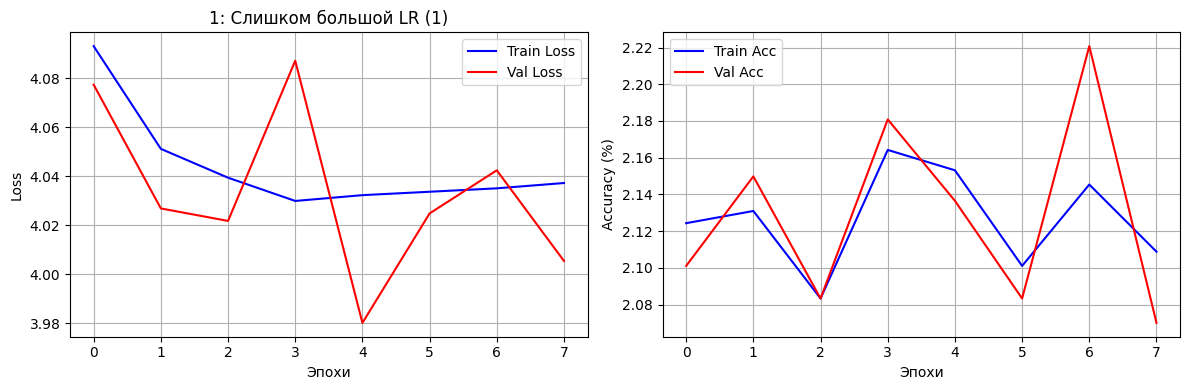

In [31]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_o1['train_loss'], 'b-', label='Train Loss')
plt.plot(history_o1['val_loss'], 'r-', label='Val Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.title('1: Слишком большой LR (1)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_o1['train_acc'], 'b-', label='Train Acc')
plt.plot(history_o1['val_acc'], 'r-', label='Val Acc')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [32]:
print("Эксперимент 2: Adam, LR = 0.0000001")


model_o2 = create_model_for_B().to(device)
optimizer = optim.Adam(model_o2.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss()

history_o2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(8):
    train_loss, train_acc = train_one_epoch(
        model_o2, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(model_o2, val_loader, criterion, device)

    history_o2['train_loss'].append(train_loss)
    history_o2['train_acc'].append(train_acc)
    history_o2['val_loss'].append(val_loss)
    history_o2['val_acc'].append(val_acc)

    print(f"Эпоха {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")

print(f"Точность на 1 эпохе: {history_o2['val_acc'][0]:.2f}%")
print(f"Точность на 8 эпохе: {history_o2['val_acc'][-1]:.2f}%")
print(f"Прирост за 8 эпох: {history_o2['val_acc'][-1] - history_o2['val_acc'][0]:.2f}%")

Эксперимент 2: Adam, LR = 0.0000001
Модель создана. Параметров: 246,063
  Батч 100/1410, Loss: 3.9163
  Батч 200/1410, Loss: 3.8915
  Батч 300/1410, Loss: 3.9929
  Батч 400/1410, Loss: 3.9283
  Батч 500/1410, Loss: 3.9499
  Батч 600/1410, Loss: 3.9561
  Батч 700/1410, Loss: 3.9756
  Батч 800/1410, Loss: 3.9923
  Батч 900/1410, Loss: 3.9518
  Батч 1000/1410, Loss: 3.9814
  Батч 1100/1410, Loss: 3.9557
  Батч 1200/1410, Loss: 3.9719
  Батч 1300/1410, Loss: 3.8288
  Батч 1400/1410, Loss: 3.8643
Эпоха 1: Train Acc=2.07%, Val Acc=2.24%
  Батч 100/1410, Loss: 4.0150
  Батч 200/1410, Loss: 3.8377
  Батч 300/1410, Loss: 3.9010
  Батч 400/1410, Loss: 3.9620
  Батч 500/1410, Loss: 3.9273
  Батч 600/1410, Loss: 3.8975
  Батч 700/1410, Loss: 3.8454
  Батч 800/1410, Loss: 3.9952
  Батч 900/1410, Loss: 3.8892
  Батч 1000/1410, Loss: 3.9284
  Батч 1100/1410, Loss: 3.9324
  Батч 1200/1410, Loss: 3.9592
  Батч 1300/1410, Loss: 3.8917
  Батч 1400/1410, Loss: 3.8953
Эпоха 2: Train Acc=2.21%, Val Acc=2.52

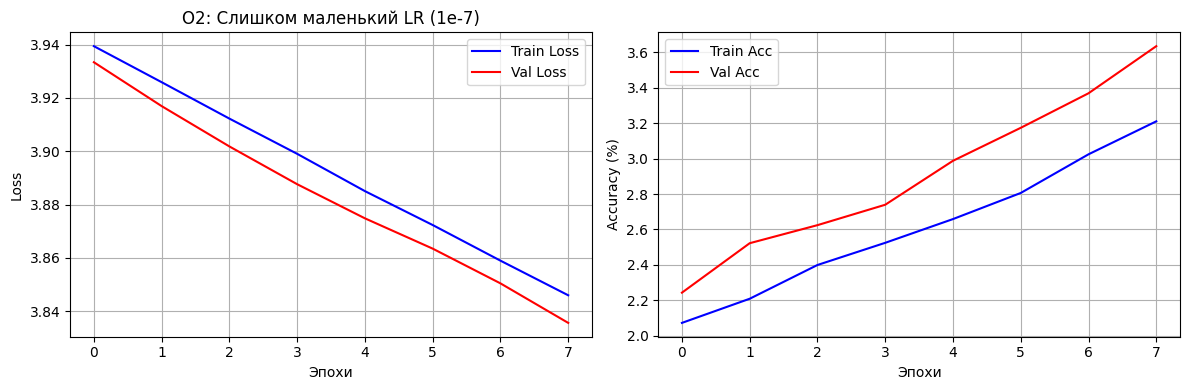

In [33]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_o2['train_loss'], 'b-', label='Train Loss')
plt.plot(history_o2['val_loss'], 'r-', label='Val Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.title('O2: Слишком маленький LR (1e-7)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_o2['train_acc'], 'b-', label='Train Acc')
plt.plot(history_o2['val_acc'], 'r-', label='Val Acc')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [34]:
print("Эксперимент 3: SGD + momentum (0.9) + weight decay (1e-4)")

model_o3 = MLP_large(dropout_prob=0.0, use_batchnorm=True).to(device)


optimizer = optim.SGD(
    model_o3.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()

history_o3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(10):
    train_loss, train_acc = train_one_epoch(
        model_o3, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(model_o3, val_loader, criterion, device)

    history_o3['train_loss'].append(train_loss)
    history_o3['train_acc'].append(train_acc)
    history_o3['val_loss'].append(val_loss)
    history_o3['val_acc'].append(val_acc)

    print(f"Эпоха {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")


print(f"Финальная точность на валидации: {history_o3['val_acc'][-1]:.2f}%")

Эксперимент 3: SGD + momentum (0.9) + weight decay (1e-4)
  Батч 100/1410, Loss: 2.1508
  Батч 200/1410, Loss: 1.3406
  Батч 300/1410, Loss: 0.8827
  Батч 400/1410, Loss: 0.7672
  Батч 500/1410, Loss: 0.8339
  Батч 600/1410, Loss: 0.5973
  Батч 700/1410, Loss: 0.7088
  Батч 800/1410, Loss: 1.1734
  Батч 900/1410, Loss: 0.7387
  Батч 1000/1410, Loss: 0.6145
  Батч 1100/1410, Loss: 0.8062
  Батч 1200/1410, Loss: 0.8249
  Батч 1300/1410, Loss: 0.9399
  Батч 1400/1410, Loss: 0.8181
Эпоха 1: Train Acc=71.53%, Val Acc=80.14%
  Батч 100/1410, Loss: 0.3895
  Батч 200/1410, Loss: 0.5851
  Батч 300/1410, Loss: 0.5445
  Батч 400/1410, Loss: 0.5520
  Батч 500/1410, Loss: 0.3749
  Батч 600/1410, Loss: 0.6207
  Батч 700/1410, Loss: 0.5518
  Батч 800/1410, Loss: 0.6281
  Батч 900/1410, Loss: 0.7709
  Батч 1000/1410, Loss: 0.5402
  Батч 1100/1410, Loss: 0.5206
  Батч 1200/1410, Loss: 0.8641
  Батч 1300/1410, Loss: 0.4193
  Батч 1400/1410, Loss: 0.4913
Эпоха 2: Train Acc=81.21%, Val Acc=81.81%
  Батч 1

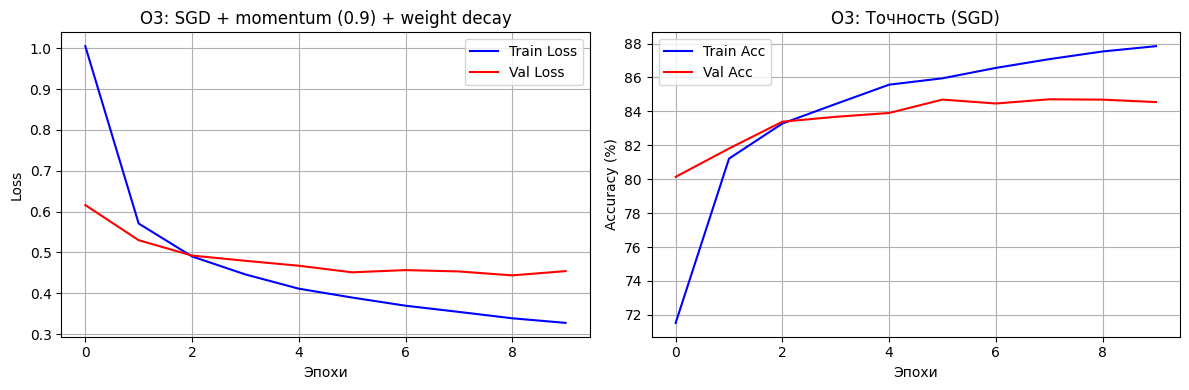

In [35]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_o3['train_loss'], 'b-', label='Train Loss')
plt.plot(history_o3['val_loss'], 'r-', label='Val Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.title('O3: SGD + momentum (0.9) + weight decay')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_o3['train_acc'], 'b-', label='Train Acc')
plt.plot(history_o3['val_acc'], 'r-', label='Val Acc')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy (%)')
plt.title('O3: Точность (SGD)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Артефакты (обязательно)
В папке homeworks/HW08-09/artifacts/ должны быть:

runs.csv – таблица результатов по всем экспериментам E1-E4 и O1-O3 (по одной строке на эксперимент).

Минимальные поля (рекомендуется именно так):

- experiment_id (E1/E2/E3/E4/O1/O2/O3)
- dataset (KMNIST/EMNIST/CIFAR10)
- seed
- model_summary (коротко: hidden sizes / activation / dropout / batchnorm)
- optimizer (Adam/SGD)
- lr
- momentum (пусто или 0 для Adam)
- weight_decay (0 если не используется)
- epochs_trained
- best_val_accuracy
- best_val_loss
- best_model.pt – сохранённый state_dict() лучшей модели (E4).

best_config.json – конфиг лучшей модели (архитектура, ключевые гиперпараметры обучения, seed, датасет).

figures/curves_best.png – график train/val loss (или loss+accuracy) для лучшего прогона (E4).

figures/curves_lr_extremes.png – график(и), показывающий(ие) поведение O1 и O2 (LR слишком большой/маленький).

можно одним рисунком на одной оси или двумя подграфиками; главное – чтобы было видно различие.

In [36]:
import os
os.makedirs('homeworks/HW08-09/artifacts/figures', exist_ok=True)

In [37]:
import pandas as pd

runs_data = [
    {
        'experiment_id': 'E1',
        'dataset': 'EMNIST',
        'seed': 17,
        'model_summary': 'MLP_large [256,128,64], ReLU, no dropout, no batchnorm',
        'optimizer': 'Adam',
        'lr': 0.001,
        'momentum': '',
        'weight_decay': 0,
        'epochs_trained': 10,
        'best_val_accuracy': 83.43,
        'best_val_loss': float(best_val_loss_e1)
    },
    {
        'experiment_id': 'E2',
        'dataset': 'EMNIST',
        'seed': 17,
        'model_summary': 'MLP_large [256,128,64], ReLU, dropout=0.3, no batchnorm',
        'optimizer': 'Adam',
        'lr': 0.001,
        'momentum': '',
        'weight_decay': 0,
        'epochs_trained': 10,
        'best_val_accuracy': 83.56,
        'best_val_loss': float(best_val_loss_e2)
    },
    {
        'experiment_id': 'E3',
        'dataset': 'EMNIST',
        'seed': 17,
        'model_summary': 'MLP_large [256,128,64], ReLU, no dropout, batchnorm',
        'optimizer': 'Adam',
        'lr': 0.001,
        'momentum': '',
        'weight_decay': 0,
        'epochs_trained': 10,
        'best_val_accuracy': 84.84,
        'best_val_loss': float(best_val_loss_e3)
    },
    {
        'experiment_id': 'E4',
        'dataset': 'EMNIST',
        'seed': 17,
        'model_summary': 'MLP_large [256,128,64], ReLU, no dropout, batchnorm',
        'optimizer': 'Adam',
        'lr': 0.001,
        'momentum': '',
        'weight_decay': 0,
        'epochs_trained': 19,
        'best_val_accuracy': 85.26,
        'best_val_loss': float(best_val_loss_e4)
    },
    {
        'experiment_id': 'O1',
        'dataset': 'EMNIST',
        'seed': 17,
        'model_summary': 'MLP_large [256,128,64], ReLU, no dropout, batchnorm',
        'optimizer': 'Adam',
        'lr': 1.0,
        'momentum': '',
        'weight_decay': 0,
        'epochs_trained': 8,
        'best_val_accuracy': 2.07,
        'best_val_loss': float(min(history_o1['val_loss']))
    },
    {
        'experiment_id': 'O2',
        'dataset': 'EMNIST',
        'seed': 17,
        'model_summary': 'MLP_large [256,128,64], ReLU, no dropout, batchnorm',
        'optimizer': 'Adam',
        'lr': 0.0000001,
        'momentum': '',
        'weight_decay': 0,
        'epochs_trained': 8,
        'best_val_accuracy': 3.85,
        'best_val_loss': float(min(history_o2['val_loss']))
    },
    {
        'experiment_id': 'O3',
        'dataset': 'EMNIST',
        'seed': 17,
        'model_summary': 'MLP_large [256,128,64], ReLU, no dropout, batchnorm',
        'optimizer': 'SGD',
        'lr': 0.01,
        'momentum': 0.9,
        'weight_decay': 0.0001,
        'epochs_trained': 10,
        'best_val_accuracy': 84.81,
        'best_val_loss': float(min(history_o3['val_loss']))
    }
]

df = pd.DataFrame(runs_data)
df.to_csv('homeworks/HW08-09/artifacts/runs.csv', index=False)

In [38]:
import shutil
shutil.copy('best_model.pt', 'homeworks/HW08-09/artifacts/best_model.pt')
print("best_model.pt скопирован в artifacts")

best_model.pt скопирован в artifacts


In [39]:
import json

best_config = {
    "model": "MLP_large",
    "hidden_sizes": [256, 128, 64],
    "activation": "ReLU",
    "dropout": 0.0,
    "batchnorm": True,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "weight_decay": 0,
    "seed": 17,
    "dataset": "EMNIST",
    "best_val_accuracy": 85.26,
    "best_epoch": 16,
    "test_accuracy": 85.06
}

with open('homeworks/HW08-09/artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)


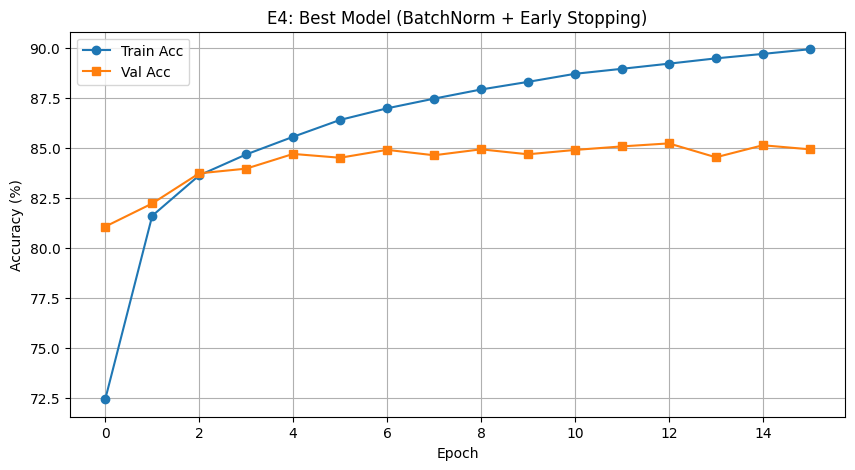

In [40]:
if 'history_e4' in dir():
    plt.figure(figsize=(10, 5))
    plt.plot(history_e4['train_acc'], label='Train Acc', marker='o')
    plt.plot(history_e4['val_acc'], label='Val Acc', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('E4: Best Model (BatchNorm + Early Stopping)')
    plt.legend()
    plt.grid(True)
    plt.savefig('homeworks/HW08-09/artifacts/figures/curves_best.png', dpi=150)
    plt.show()
else:
    print("history_e4 не найдена")

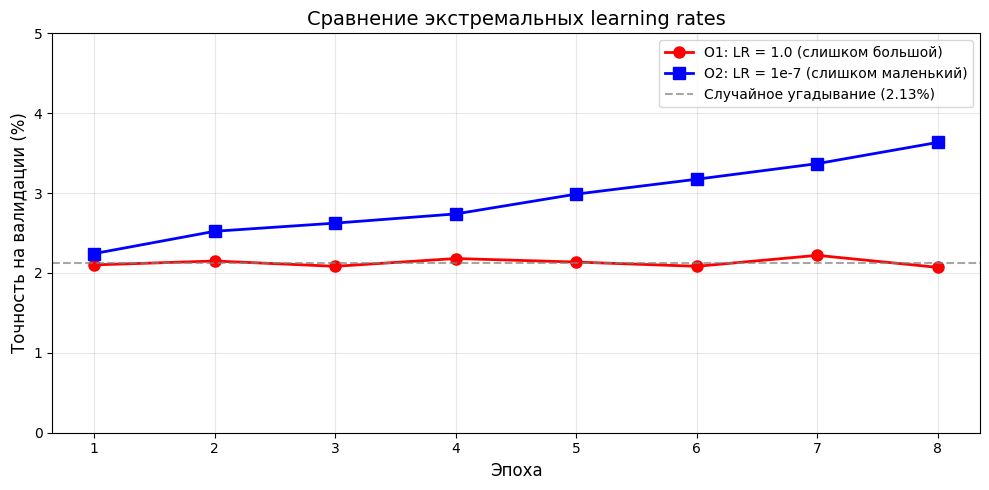

In [41]:
import matplotlib.pyplot as plt
import numpy as np

o1_acc = history_o1['val_acc']
o2_acc = history_o2['val_acc']

epochs = np.arange(1, len(o1_acc) + 1)


random_guess = 100/47  # 2.13%

plt.figure(figsize=(10, 5))

plt.plot(epochs, o1_acc, 'r-o', linewidth=2, markersize=8,
         label='O1: LR = 1.0 (слишком большой)')
plt.plot(epochs, o2_acc, 'b-s', linewidth=2, markersize=8,
         label='O2: LR = 1e-7 (слишком маленький)')
plt.axhline(y=random_guess, color='gray', linestyle='--', alpha=0.7,
            label=f'Случайное угадывание ({random_guess:.2f}%)')

plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Точность на валидации (%)', fontsize=12)
plt.title('Сравнение экстремальных learning rates', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(epochs)
plt.ylim(0, 5)

plt.tight_layout()
plt.savefig('homeworks/HW08-09/artifacts/figures/curves_lr_extremes.png', dpi=150)
plt.show()

